## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/yem_mvam")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (1290, 10)
bivariate_df: (1290, 14)
joint_df: (430, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abyan,log_exp_pp,0.375332,0.041610,0.776625,0.735014,0.454034,0.454034
1,cNF,1,Abyan,rCSI,1.547233,0.502459,11.524880,11.022421,0.094786,0.094786
2,cNF,1,Abyan,FCS,1.703892,0.365091,13.063009,12.697918,0.105435,0.105435
3,cNF,1,Ad Dali',log_exp_pp,0.689981,0.037280,0.735370,0.698090,0.934981,0.934981
4,cNF,1,Ad Dali',rCSI,1.626511,0.208539,11.464334,11.255795,0.125977,0.125977


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Abyan,log_exp_pp,rCSI,log_exp_pp__rCSI,0.005089,0.070789,0.065700,0.025326,0.015205,-0.010121,-3.989083,0.000000
1,cNF,1,Abyan,log_exp_pp,FCS,log_exp_pp__FCS,0.095590,-0.052383,0.147974,0.006456,0.105887,0.099431,1.423273,1.000000
2,cNF,1,Abyan,rCSI,FCS,rCSI__FCS,-0.175938,-0.130277,0.045660,0.019883,0.178759,0.158876,0.162246,0.162246
3,cNF,1,Ad Dali',log_exp_pp,rCSI,log_exp_pp__rCSI,0.031481,0.083096,0.051615,0.032585,0.007871,-0.024713,-0.770049,0.000000
4,cNF,1,Ad Dali',log_exp_pp,FCS,log_exp_pp__FCS,0.031793,-0.216281,0.248075,0.012298,0.056929,0.044631,5.282797,1.000000


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abyan,0.531674,1827,1827,0.145281,0.491911,0.346630,1.114713,1.0
1,cNF,1,Ad Dali',1.004263,1648,1648,0.152616,0.554548,0.401932,2.118883,1.0
2,cNF,1,Aden,0.950261,1521,1521,0.151073,0.587801,0.436728,1.829943,1.0
3,cNF,1,Al Bayda,0.552088,2675,2675,0.115947,0.473340,0.357394,1.220339,1.0
4,cNF,1,Al Hodeidah,0.416646,4484,4484,0.104815,0.336222,0.231408,1.347543,1.0


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Abyan,0.243940
1,CTGAN,1,Ad Dali',0.125664
2,CTGAN,1,Aden,0.139393
3,CTGAN,1,Al Bayda,0.206842
4,CTGAN,1,Al Hodeidah,0.337116


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Abyan,0.587909
1,CTGAN,1,Ad Dali',0.400907
2,CTGAN,1,Aden,0.385824
3,CTGAN,1,Al Bayda,0.233457
4,CTGAN,1,Al Hodeidah,0.761107


,model,seed,adm1,joint_norm
0,cNF,1,Abyan,1.0
1,cNF,1,Ad Dali',1.0
2,cNF,1,Aden,1.0
3,cNF,1,Al Bayda,1.0
4,cNF,1,Al Hodeidah,1.0


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (430, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abyan,0.243940,0.587909,1.000000
1,CTGAN,1,Ad Dali',0.125664,0.400907,0.557087
2,CTGAN,1,Aden,0.139393,0.385824,0.542415
3,CTGAN,1,Al Bayda,0.206842,0.233457,1.000000
4,CTGAN,1,Al Hodeidah,0.337116,0.761107,1.000000


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/yem_mvam/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.235415,0.500515,0.860151
1,CTGAN,2,0.271487,0.259633,0.935123
2,CTGAN,3,0.326442,0.538986,0.968831
3,CTGAN,4,0.227116,0.699212,0.934394
4,CTGAN,5,0.258861,0.773736,0.892830


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.263864,0.039240,0.554416,0.199442,0.918266,0.042206
1,NF,0.096504,0.067209,0.462759,0.203786,0.541406,0.193928
2,TVAE,0.409334,0.121127,0.430543,0.159311,0.984793,0.025466
3,cNF,0.260066,0.114350,0.526029,0.109607,0.862422,0.160494


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.049507,0.097157,0.119233
1,NF,0.035915,0.110368,0.106478
2,TVAE,0.118528,0.134348,0.032629
3,cNF,0.067866,0.127475,0.092000


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.263864,0.039240,0.554416,0.199442,0.918266,0.042206,0.049507,0.097157,0.119233
1,NF,0.096504,0.067209,0.462759,0.203786,0.541406,0.193928,0.035915,0.110368,0.106478
2,TVAE,0.409334,0.121127,0.430543,0.159311,0.984793,0.025466,0.118528,0.134348,0.032629
3,cNF,0.260066,0.114350,0.526029,0.109607,0.862422,0.160494,0.067866,0.127475,0.092000


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.736136,0.039240,0.445584,0.199442,0.081734,0.042206,0.049507,0.097157,0.119233
1,NF,0.903496,0.067209,0.537241,0.203786,0.458594,0.193928,0.035915,0.110368,0.106478
2,TVAE,0.590666,0.121127,0.569457,0.159311,0.015207,0.025466,0.118528,0.134348,0.032629
3,cNF,0.739934,0.114350,0.473971,0.109607,0.137578,0.160494,0.067866,0.127475,0.092000


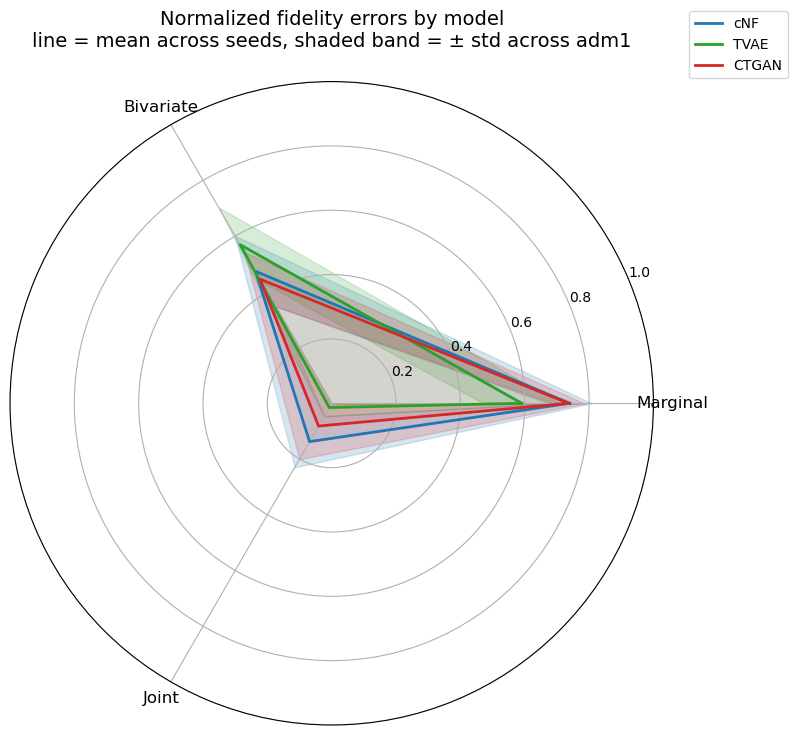

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/yem_mvam")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/yem_mvam")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (430, 6)
recall_df: (430, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abyan,0.243940,0.587909,1.000000
1,CTGAN,1,Ad Dali',0.125664,0.400907,0.557087
2,CTGAN,1,Aden,0.139393,0.385824,0.542415
3,CTGAN,1,Al Bayda,0.206842,0.233457,1.000000
4,CTGAN,1,Al Hodeidah,0.337116,0.761107,1.000000


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Abyan,0.979201,1789,1827,1827,0.5
1,cNF,1,Ad Dali',0.966626,1593,1648,1648,0.5
2,cNF,1,Aden,0.967784,1472,1521,1521,0.5
3,cNF,1,Al Bayda,0.987290,2641,2675,2675,0.5
4,cNF,1,Al Hodeidah,0.982159,4404,4484,4484,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Abyan,0.243940,0.587909,1.000000,0.610616
1,CTGAN,1,Ad Dali',0.125664,0.400907,0.557087,0.361219
2,CTGAN,1,Aden,0.139393,0.385824,0.542415,0.355878
3,CTGAN,1,Al Bayda,0.206842,0.233457,1.000000,0.480100
4,CTGAN,1,Al Hodeidah,0.337116,0.761107,1.000000,0.699408


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (430, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Abyan,0.610616,0.969896
1,CTGAN,1,Ad Dali',0.361219,0.976942
2,CTGAN,1,Aden,0.355878,0.965812
3,CTGAN,1,Al Bayda,0.480100,0.977570
4,CTGAN,1,Al Hodeidah,0.699408,0.960972


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.961926,0.014193,0.578849,0.117748,110
1,NF,0.972035,0.038675,0.366890,0.166271,110
2,TVAE,0.745176,0.275622,0.612599,0.147414,100
3,cNF,0.969867,0.043280,0.549506,0.156247,110


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.969867,0.043280,0.549506,0.156247,110
1,TVAE,0.745176,0.275622,0.612599,0.147414,100
2,CTGAN,0.961926,0.014193,0.578849,0.117748,110


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.969867,0.043280,0.549506,0.156247,110,0.450494
1,TVAE,0.745176,0.275622,0.612599,0.147414,100,0.387401
2,CTGAN,0.961926,0.014193,0.578849,0.117748,110,0.421151


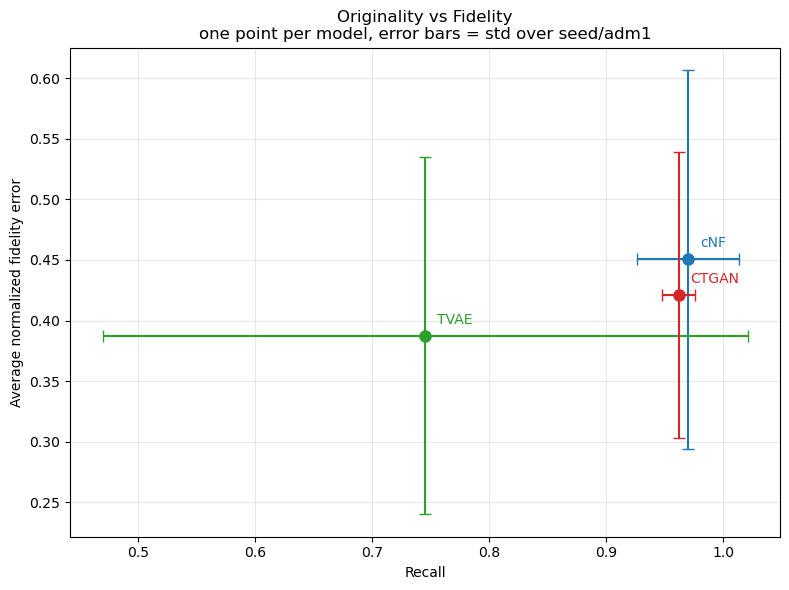

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()